In [1]:
import pandas as pd

df = pd.read_csv("email.csv")  # your file name
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print(df.columns)

Index(['Category', 'Message'], dtype='object')


In [15]:
df['Category'].value_counts(normalize=True)


Category
ham               0.865781
spam              0.134039
{"mode":"full"    0.000179
Name: proportion, dtype: float64

In [2]:
df = df.dropna()

In [22]:
df=df[:-1]

In [4]:
from sklearn.model_selection import train_test_split

X = df['Message']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
import re
import string

def preprocess(Message):
    Message = Message.lower()
    Message = re.sub(r'\d+', '', Message)
    Message = Message.translate(str.maketrans('', '', string.punctuation))
    return Message

X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Logistic Regression
y_pred_lr = lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

# Naive Bayes
y_pred_nb = nb.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115

[[966   0]
 [ 31 118]]
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.71      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115

[[966   0]
 [ 43 106]]


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

In [ ]:
df = pd.read_csv("email.csv")
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})
X_train, X_test, y_train, y_test = train_test_split(
    df['Message'],
    df['Category'],
    test_size=0.2,
    random_state=42,
    stratify=df['Category']
)

ValueError: Input y contains NaN.

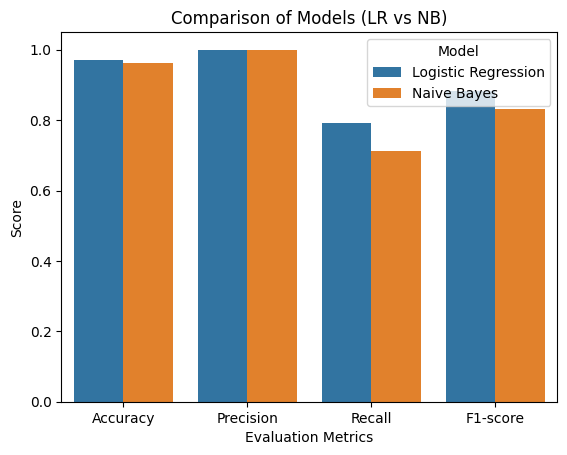

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
metrics = {
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, pos_label='spam'),
        precision_score(y_test, y_pred_nb, pos_label='spam')
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, pos_label='spam'),
        recall_score(y_test, y_pred_nb, pos_label='spam')
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr, pos_label='spam'),
        f1_score(y_test, y_pred_nb, pos_label='spam')
    ]
}

df_metrics = pd.DataFrame(metrics)

# Convert to long format
df_melt = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure()
sns.barplot(data=df_melt, x='Metric', y='Score', hue='Model')
plt.title("Comparison of Models (LR vs NB)")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.legend(title="Model")
plt.show()

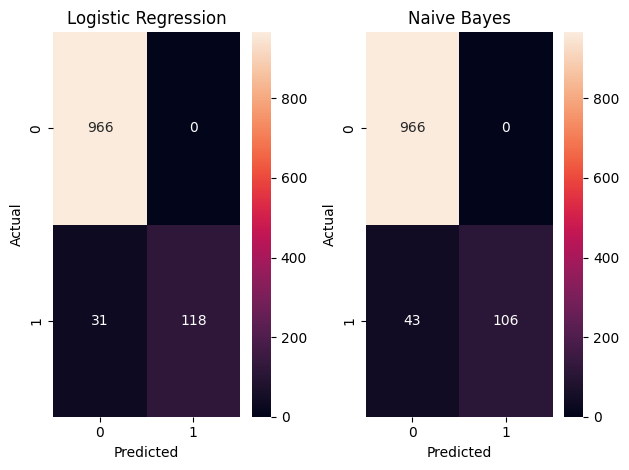

In [14]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, axes = plt.subplots(1, 2)

sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_nb, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Naive Bayes")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [16]:
import time

# Logistic Regression time
start = time.time()
lr.fit(X_train_tfidf, y_train)
lr_time = time.time() - start

# Naive Bayes time
start = time.time()
nb.fit(X_train_tfidf, y_train)
nb_time = time.time() - start

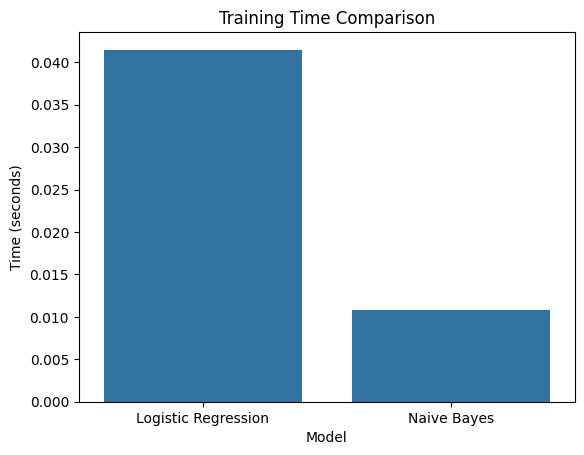

In [17]:
models = ['Logistic Regression', 'Naive Bayes']
times = [lr_time, nb_time]

plt.figure()
sns.barplot(x=models, y=times)
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.show()

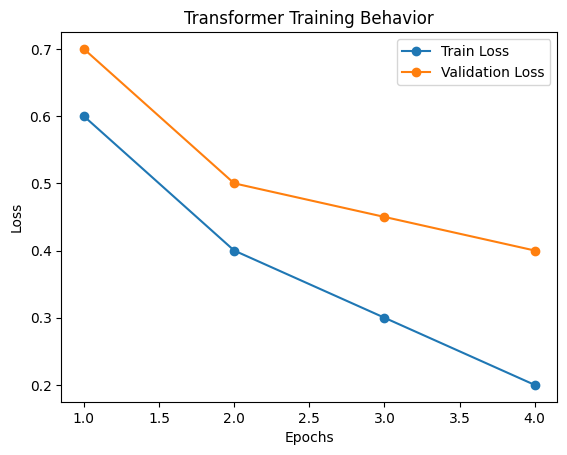

In [18]:
# Example training behavior
epochs = [1, 2, 3, 4]
train_loss = [0.6, 0.4, 0.3, 0.2]
val_loss = [0.7, 0.5, 0.45, 0.4]

plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.title("Transformer Training Behavior")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()